In [10]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

from unityvr.preproc import logproc
from unityvr.viz import viz

In [19]:
dirName = '/Users/hamida/Desktop/'
fileName = "Log_2025-08-29_17-38-40_trial-code-check-fixedcylinder.json"

dat = logproc.openUnityLog(dirName, fileName)

for i in range(5):
    print(dat[i]['frame'])
    print(json.dumps(dat[i], sort_keys=True, indent=4))

0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "headerNotes": "20degspot-fh-125degpersec-120fps-anglerange100deg--panWidth_px-389-panHeight_px-151                                                                                                                                                                                 ",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "heightPixels": 720,
    "refreshRateHz": 120,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "widthPixels": 480
}
1.0
{
    "ficTracBallRadius": 0.4000000059604645,
    "ficTracServerAddress": "127.0.0.1",
    "ficTracServerPort": 2000,
    "ficTracSmoothingCount": 1,
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
1.0
{
    "colliderType": "MeshCollider",
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "meshGameObjectPath": "Fly/FlyCamera4/FlyCamera4Screen",
    "timeSecs": 0.0,
 

In [12]:
# extract timeSecs from dat
timeSecs = [d['timeSecs'] for d in dat]
# timeSecs

In [13]:
# group by frame
dat = pd.DataFrame(dat)

In [14]:
dat

,timeSecs,frame,timeSecsAfterSplash,frameAfterSplash,headerNotes,refreshRateHz,widthPixels,heightPixels,ficTracServerAddress,ficTracServerPort,...,tracePD,imgFrameTrigger,indexFrameTrigger,numberOfEntriesWritten,splashScreenDurationSec,backgroundsTotalDurationSec,expectedBackgroundsTotalDurationSecs,backgroundsTotalCount,complete,skippedBackgrounds
0,0.000000,0.0,0.000000,0.0,20degspot-fh-125degpersec-120fps-anglerange100...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000000,0.0,0.000000,0.0,NaN,120.0,480.0,720.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000000,1.0,0.000000,1.0,NaN,NaN,NaN,NaN,127.0.0.1,2000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.000000,1.0,0.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.000000,1.0,0.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210997,159.366730,17166.0,159.366730,17166.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.043624,9.950429,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210998,159.366730,17166.0,159.366730,17166.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.112219,9.951395,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210999,159.366730,17166.0,159.366730,17166.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090642,-9.728173,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211000,159.366730,17166.0,159.366730,17166.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.98,159.382004,159.373245,19200.0,False,"[1, 22, 36, 40, 43, 45, 48, 49, 56, 63, 68, 73..."


In [15]:
#differene between timeSecs per frame
dat['timeinterp'] = dat['timeSecs'].diff().fillna(0)

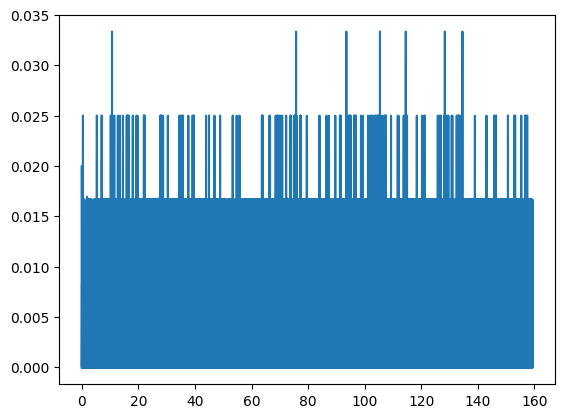

In [16]:
#plot timeinterp vs timeSecs
plt.plot(dat['timeSecs'], dat['timeinterp'])